In [2]:
import os

from anatomy import *
import svg

import math
import random
import numpy as np

import matplotlib.pyplot as plt

In [218]:
def extend_axon(x, x_sec, y_sec, shape_points):
    '''
    x : intrinsic x
    x_sec : cartesian x
    y_sec : cartesian y
    '''
    # region :  EC [0, 0.2], Sub [0.2, 0.51], CA1 [ 0.51, 0.7], CA3 [ 0.7, 0.86], DG [ 0.86, 1.]
    coords = np.array([[x_sec, y_sec, 0]])

    min_dist = 0 # distance of soma to border between CA1 and CA3

    if x <= 0.78:
        my_shape = shape_points[70:int(x*100)+1]
    
        for i in range(len(my_shape)-1):
            min_dist += math.sqrt((my_shape[i,0] - my_shape[i+1,0])**2 + (my_shape[i,1] - my_shape[i+1,1])**2)

        dist_target = min_dist + 500 + 2050 * random.random() #2050 + random.uniform(0, 3120/2) #830.41*1.5
    else: 
        my_shape = shape_points[60:int(x*100)+1]
    
        for i in range(len(my_shape)-1):
            min_dist += math.sqrt((my_shape[i,0] - my_shape[i+1,0])**2 + (my_shape[i,1] - my_shape[i+1,1])**2)

        dist_target = min_dist + 500 + 2050 * random.random() #4098 + random.uniform(3120/2, 3120) # 2145.25*1.5; 630*1..5

    axon_depth = get_y_axonal_extension_2(int(x*100), x_sec, y_sec, shape_points)
    pre_axonal_extension = build_axonal_extension(shape_points, axon_depth)
    pre_axonal_extension = np.flip(pre_axonal_extension, axis=0)
    pre_axonal_extension = pre_axonal_extension[100-int(x*100):]

    n_points = len(pre_axonal_extension)
    total_length = 0

    coords = np.append(coords, [[pre_axonal_extension[0,0], pre_axonal_extension[0,1], 0]], axis=0)

    for i in range(n_points - 1):
        total_length += math.sqrt((pre_axonal_extension[i, 0] - pre_axonal_extension[i+1, 0])**2 + (pre_axonal_extension[i, 1] - pre_axonal_extension[i+1, 1])**2)
        if total_length <= dist_target:
            coords = np.append(coords, [[pre_axonal_extension[i+1,0], pre_axonal_extension[i+1,1], 0]], axis=0)
        else:
            break

    return coords, total_length

In [105]:
random.uniform(3120/2, 3120)

1599.9128285367299

In [100]:
my_shape = new_points[51:69]

In [103]:
3121/2


1560.5

In [101]:
my_length = 0

for i in range(len(my_shape)-1):
    my_length += math.sqrt((my_shape[i,0]-my_shape[i+1,0])**2 + (my_shape[i,1]-my_shape[i+1,1])**2)

my_length


4098.974260197856

# create shape

In [4]:
SVG_PATH = "../svg_files/"
coords_ca3 = np.load(os.path.join('../positions_correct_layers_thickness', 'ca3',  'pyr_coordinates.npy'))

In [5]:
verts, codes, skeleton_points, nodes = svg.convert(svg.get(SVG_PATH + "hpf_update.svg", "skeleton"))

In [6]:
converted_verts = np.zeros(np.shape(verts))
for i in range(len(verts)):
    converted_verts[i][0] = convert_to_μm(verts[i][0])

for i in range(len(verts)):
    converted_verts[i][1] = convert_to_μm(verts[i][1])

In [7]:
T = np.arange(0, 1.01, 0.01)

In [8]:
points = []
for t in T:
    points.extend(stack_bezier(t,converted_verts[:4], converted_verts[3:]))
points = np.array(points).reshape(-1, 2)

In [10]:
new_points = []
for t in T:
    new_points.extend(mapping_bezier(t, points, converted_verts))
new_points = np.array(new_points).reshape(-1, 2)

In [12]:
thickness = 1.5*1e3

In [13]:
c1, d1, idx = external_shape(new_points, thickness/2)

In [183]:
trajectories = []
lengths = []

In [184]:
for i in range(len(coords_ca3)):
    coords, length = extend_axon(coords_ca3[i, 3], coords_ca3[i,0], coords_ca3[i,1], new_points)
    trajectories.append(coords)
    lengths.append(length)

In [219]:
trajectories_2 = []
lengths_2 = []

In [220]:
for i in range(len(coords_ca3)):
    coords, length = extend_axon(coords_ca3[i, 3], coords_ca3[i,0], coords_ca3[i,1], new_points)
    trajectories_2.append(coords)
    lengths_2.append(length)

In [221]:
trajectories_2[0]

array([[ 887.80453216, 1997.65390776,    0.        ],
       [ 763.39490444, 2132.79403994,    0.        ],
       [ 645.05463241, 2404.54111338,    0.        ]])

In [222]:
lengths_2

[615.8600929853733,
 1866.7477232161134,
 1495.6939469003516,
 2463.1315652280987,
 3112.598189336178,
 2097.3951675666904,
 1976.5262659714672,
 1946.2661647133455,
 3825.347987173863,
 2862.002800166289,
 3724.9169727508443,
 2692.5086605748497,
 2772.222301957271,
 6343.73387384525,
 5039.015660665537,
 6971.1621310492765,
 7812.944562113236,
 6103.0040571530835,
 7358.0344844767615,
 6526.825018677103,
 6067.041283759656,
 7435.69954868571,
 7060.333899095275,
 6193.719841441979,
 8198.327300898984,
 7469.893780341804]

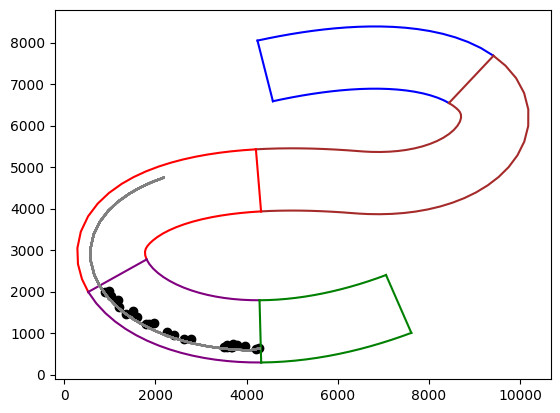

In [250]:
fig, ax = plt.subplots()
region_size = [20, 31, 19, 16, 14]
regions_idx = [0]
total_length = 0
for i in range(len(region_size)):
    total_length += region_size[i]
    regions_idx.append(total_length)
region = ['EC', 'Subiculum', 'CA1', 'CA3', 'DG']
color = ['blue', 'brown', 'red', 'purple', 'green']

for i in range(len(regions_idx)-1):
    # ax.plot(new_points[regions_idx[i]:regions_idx[i+1]+1, 0], new_points[regions_idx[i]:regions_idx[i+1]+1, 1], '--', color='black')
    ax.plot(c1[regions_idx[i]:regions_idx[i+1]+1, 0], c1[regions_idx[i]:regions_idx[i+1]+1, 1], color=color[i])
    ax.plot(d1[regions_idx[i]:regions_idx[i+1]+1, 0], d1[regions_idx[i]:regions_idx[i+1]+1, 1], color=color[i])
    ax.plot([d1[regions_idx[i], 0], c1[regions_idx[i], 0]], [d1[regions_idx[i], 1], c1[regions_idx[i], 1]], color=color[i])
ax.plot([d1[regions_idx[-1], 0], c1[regions_idx[-1], 0]], [d1[regions_idx[-1], 1], c1[regions_idx[-1], 1]], color=color[-1])
# ax.plot(new_points[:,0], new_points[:,1], color='red')
for i in range(len(trajectories_2)):
    ax.plot(trajectories_2[25][:,0], trajectories_2[25][:,1], color='grey')

# ax.plot(trajectories[26][:,0], trajectories[26][:,1], color='grey')
# ax.plot(coords[:,0], coords[:,1], color='red')
# ax.scatter(new_points[70,0], new_points[70,1])
for i in range(len(coords_ca3)):
    ax.scatter(coords_ca3[i,0], coords_ca3[i,1], color='black')
plt.show()


In [163]:
test_len = 0
test_shape=new_points[70:int(coords_ca3[2,3]*100)+1]
print(test_shape)
for i in range(len(test_shape)-1):
    test_len += math.sqrt((test_shape[i,0]-test_shape[i+1,0])**2 + (test_shape[i,1]-test_shape[i+1,1])**2)

test_len

[[1168.84163436 2381.21152177]
 [1285.65194475 2190.563271  ]]


223.58757598715576

In [216]:
coords_ca3[11,3]

0.772087284845256

In [251]:
save_name = os.path.join('../positions_correct_layers_thickness', 'ca3',  'schaffer_trajectories.npy')
np.save(save_name, np.array(trajectories_2, dtype=object), allow_pickle=True)

In [252]:
test_trajectories = np.load(save_name, allow_pickle=True)

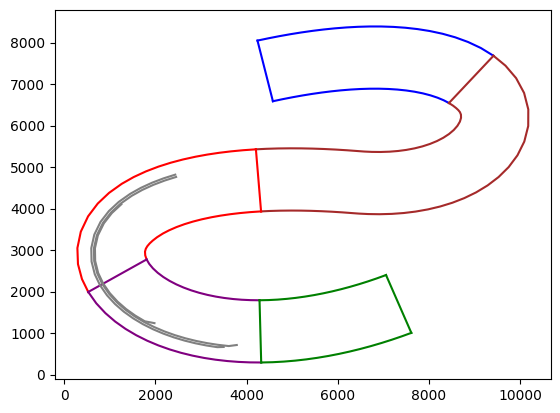

In [290]:
fig, ax = plt.subplots()
region_size = [20, 31, 19, 16, 14]
regions_idx = [0]
total_length = 0
for i in range(len(region_size)):
    total_length += region_size[i]
    regions_idx.append(total_length)
region = ['EC', 'Subiculum', 'CA1', 'CA3', 'DG']
color = ['blue', 'brown', 'red', 'purple', 'green']

for i in range(len(regions_idx)-1):
    # ax.plot(new_points[regions_idx[i]:regions_idx[i+1]+1, 0], new_points[regions_idx[i]:regions_idx[i+1]+1, 1], '--', color='black')
    ax.plot(c1[regions_idx[i]:regions_idx[i+1]+1, 0], c1[regions_idx[i]:regions_idx[i+1]+1, 1], color=color[i])
    ax.plot(d1[regions_idx[i]:regions_idx[i+1]+1, 0], d1[regions_idx[i]:regions_idx[i+1]+1, 1], color=color[i])
    ax.plot([d1[regions_idx[i], 0], c1[regions_idx[i], 0]], [d1[regions_idx[i], 1], c1[regions_idx[i], 1]], color=color[i])
ax.plot([d1[regions_idx[-1], 0], c1[regions_idx[-1], 0]], [d1[regions_idx[-1], 1], c1[regions_idx[-1], 1]], color=color[-1])
# ax.plot(new_points[:,0], new_points[:,1], color='red')
# for i in range(len(test_trajectories)):
#     ax.plot(test_trajectories[i][:13,0], test_trajectories[i][:13,1], color='grey')
ax.plot(test_trajectories[15][:,0], test_trajectories[15][:,1], color='grey')
ax.plot(test_trajectories[10][:,0], test_trajectories[10][:,1], color='grey')
ax.plot(test_trajectories[22][:,0], test_trajectories[22][:,1], color='grey')

# ax.plot(trajectories[26][:,0], trajectories[26][:,1], color='grey')
# ax.plot(coords[:,0], coords[:,1], color='red')
# ax.scatter(new_points[70,0], new_points[70,1])
# for i in range(len(coords_ca3)):
#     ax.scatter(coords_ca3[i,0], coords_ca3[i,1], color='black')
plt.show()
